## Chapter 4: Geocentric models

### Simulate random walks

In [3]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import scipy.stats as stats

from scipy.interpolate import griddata

g++ not available, if using conda: `conda install gxx`


In [7]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

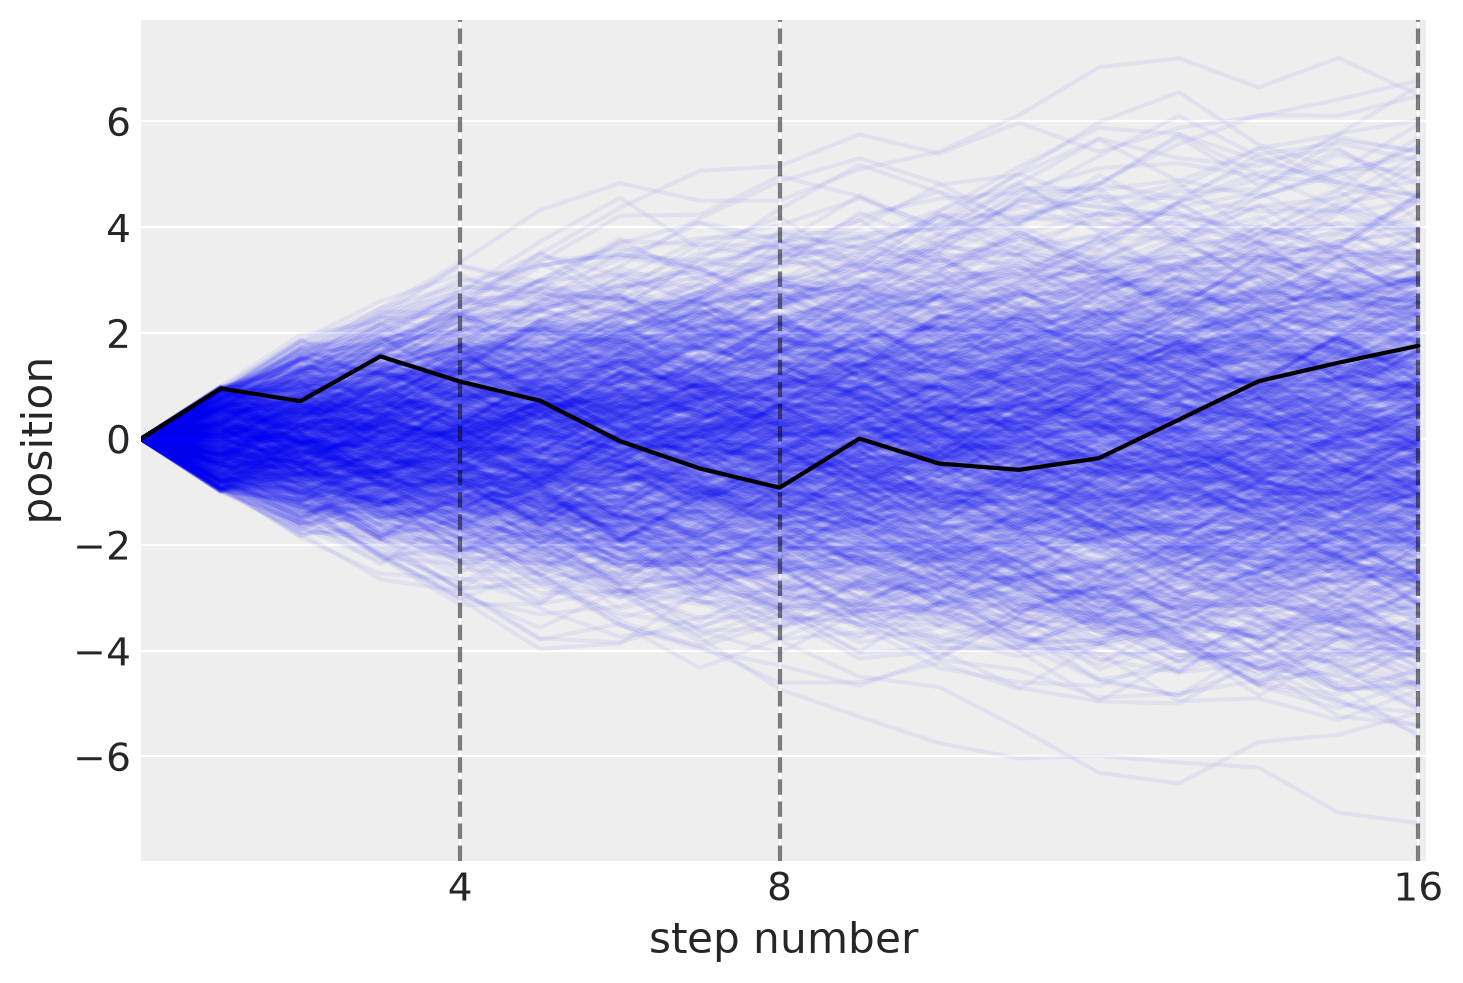

In [8]:
step_rng = np.random.default_rng(1234)

steps = 16
repetitions = 1000
show_steps = [4, 8, 16]
x = np.zeros([steps + 1, repetitions])
for i in range(x.shape[1]):
    x[1:, i] = np.cumsum(step_rng.uniform(-1, 1, steps))

fig, ax = plt.subplots()
plt.plot(range(0, steps + 1), x[:, :], c="b", alpha=0.05)
plt.plot(range(0, steps + 1), x[:, 0], c="k")
for step in show_steps:
    plt.axvline(step, linestyle="--", c="k", alpha=0.5)

plt.xlabel("step number")
plt.ylabel("position")
ax.set_xticks(show_steps)
plt.xlim(0, step + 0.1)
plt.show()

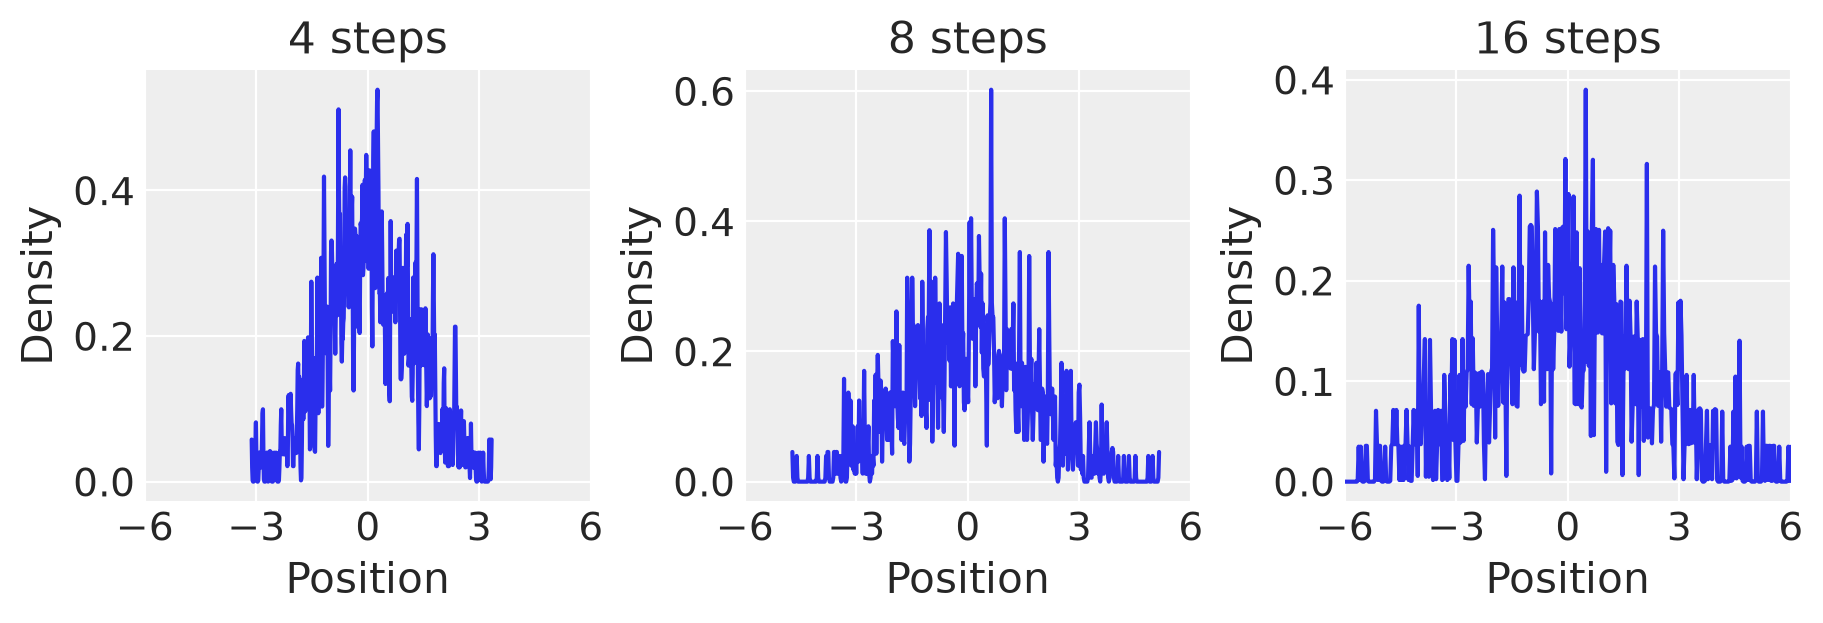

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharex=True)

for step, ax in zip(show_steps, axs):
    x_grid, density, _ = az.kde(x[step, :], bw=0.01)
    ax.set_title(f"{step} steps")
    ax.set_ylabel("Density")
    ax.set_xlabel("Position")
    ax.set_xlim(-6, 6)
    ax.set_xticks([-6, -3, 0, 3, 6])
    ax.plot(x_grid, density)

### 4.1 Normal distributions

Any process that adds together random values from the same distribution converges to a normal. Each addition in the above example can be seen as a deviation from the mean value: once summed they will most likely (as most addition/subtraction combinations are around the mean) be relatively close to the mean. The underlying distribution can be anything but convergence to a normal distribution will (eventually, with speed depending on the distribution) occur.

The Gaussian distribution is the most natural expression of 'ignorance' - when modelling on PyMC an understand prior would just be a normal distribution (if no other useful information is known). Commonly, in financial time series, the Gaussian is not a good prior because of the Gaussian's thin tails: there is low probability for rare events. Instead distributions with heavier tails (like Student-t) are more appropriate. Financial time series may look Gaussian in the short term but over a longer period will usually have heavier tails.

## 4.2 Describing models

Methodology for describing statistical models:

    1. Identify variables: if observable, they are data; if unobservable they are parameters.
    2. Define each variable in terms of other variables or in terms of a probability distribution.
    3. The combination of (2) gives a model that generates hypothetical observations that can be compared to the real ones.

For example,

$$
\begin{aligned}
y_i &\sim \text{Normal}(\mu_i, \sigma) \\
\mu_i &= \beta x_i \\
\beta &\sim \text{Normal}(0, 10) \\
\sigma &\sim \text{Exponential}(1) \\
x_i &\sim \text{Normal}(0, 1)
\end{aligned}
$$

## 4.3 Gaussian model of height

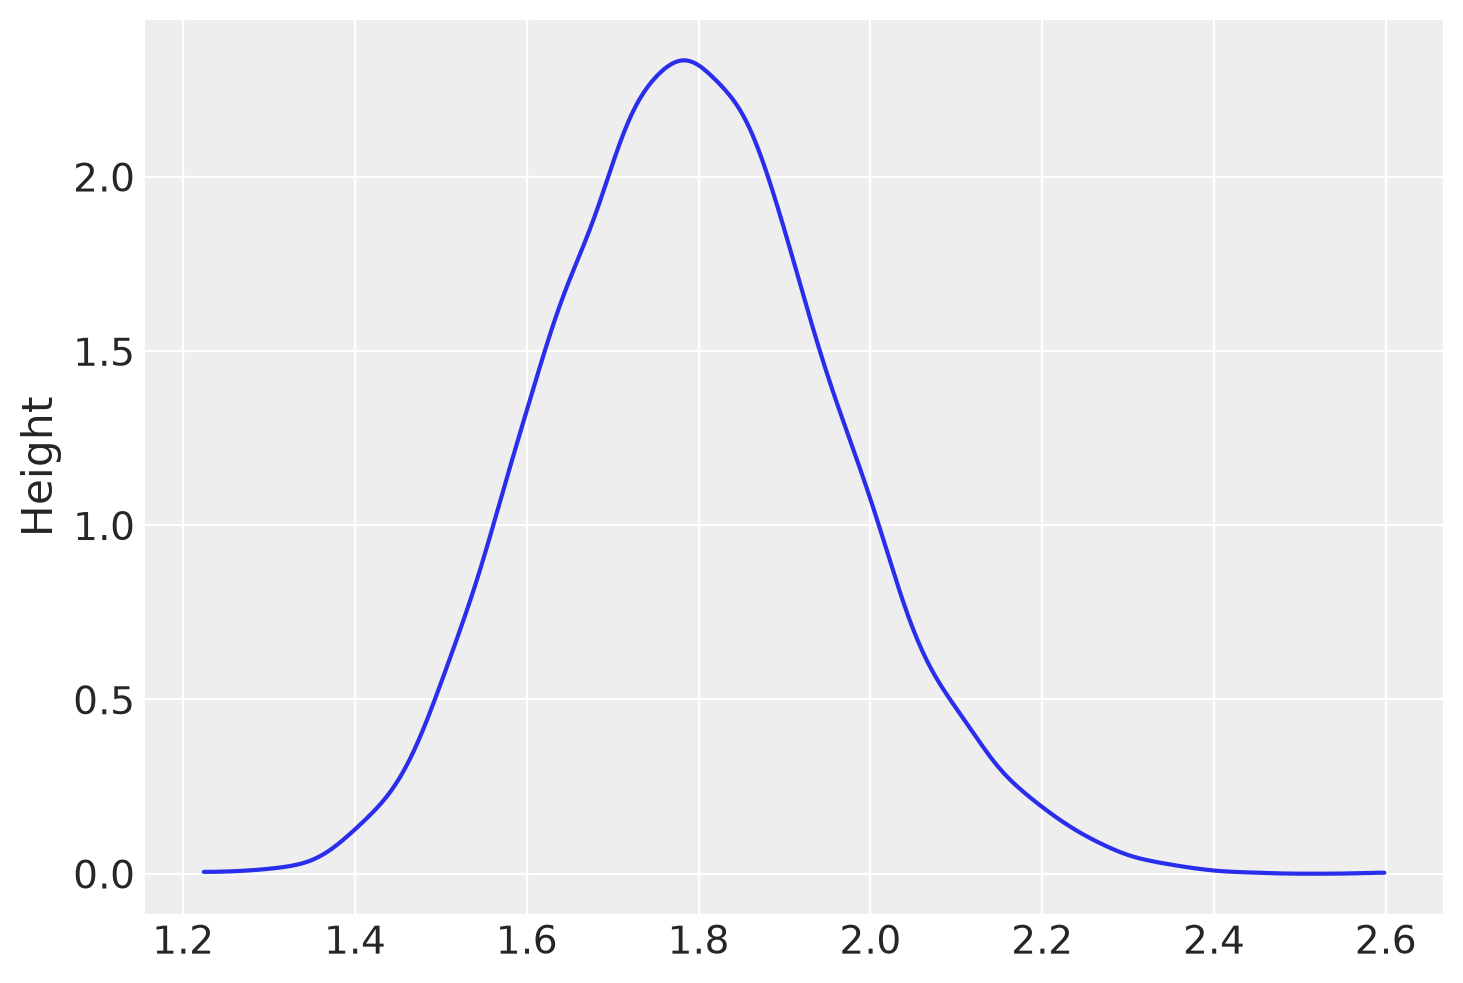

In [19]:
pos = rng.uniform(1, 1.1, size=(12, 10000)).prod(0)
x_grid, density, _ = az.kde(pos)

plt.plot(x_grid, density)
plt.ylabel("Height")
plt.show()

To fit the above with some Gaussian distribution, you can define height, h as a normal (likelihood) with some mu and sigma: mu and sigma are then defined with priors of a normal distribution and uniform distribution respectively. The sigma prior can be defined as uniform just to constrain it to be postive from 0-50cm.

##### Use sensible limits within context of your model to define priors. Having large standard deviations can negatively affect your prior: confine sigma to a reasonable value.

### 4.4 Linear prediction

Priors need not be perfect to work; they must just encode states of information before seeing data. You will usually know a plausible range/barriers for the priors. Priors must not be based on data, but rather general knowledge.

##### Plot posterior distributions and posterior predictions always.

Use ArviZ to generate distributions of psoterior values for priors. ArviZ can be used to show summary tables and most importantly plots. PyMC handles the quadratic approximation to estimate the maximum likelihood values generated from the posteriors to yield the simulated hypothetical data.